In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import yaml
from pathlib import Path
from dask.distributed import Client
import dask.dataframe as dd
import networkx as nx
import sys
import pandas as pd
import ipycytoscape
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import intervals
import pygtrie
import seaborn as sns


/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [3]:
app_name = "montage"
cp_dir="/p/lustre2/pandey2/cp_dir/montage/"

In [4]:
with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
    dlp_yaml = yaml.safe_load(file)
    app_root = dlp_yaml["app"]
sys.path.insert(0, app_root)

import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
from dfanalyzer.graph_visualization.cytoscape import GraphFunctions, CytoGraph
from dfanalyzer.graph import DFGrepInterference, DFGrepWorkflow 
from dfanalyzer.plots import GrepIOPlots

def binned_category():
    if app_name == "mummi":
        size_bins = [
        0, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288,
        1048576, 2097152, 4194304, 8388608, 16777216, 33554432, 67108864, 134217728,
        268435456, 536870912, 1073741824, float('inf')
        ]
        size_labels = [
        '<512B', '512B-1KB', '1-2KB', '2-4KB', '4-8KB', '8-16KB', '16-32KB', '32-64KB',
        '64-128KB', '128-256KB', '256-512KB', '512KB-1MB', '1-2MB', '2-4MB', '4-8MB',
        '8-16MB', '16-32MB', '32-64MB', '64-128MB', '128-256MB', '256-512MB', '512MB-1GB', '>1GB'
        ]
        degree_bins = [
            0, 2, 3, 4, 5, 6, 10, 20, float('inf')
        ]
        degree_labels = [
            '1', '2', '3', '4', '5', '5-10', '10-20', '>20',
        ]
    
    elif app_name == "montage":
        size_bins = [
        0,128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144
        ]
        size_labels = [
        '<128B','128B-256B','256B-512B', '512B-1KB', '1-2KB', '2-4KB', '4-8KB', '8-16KB', '16-32KB', '32-64KB',
        '64-128KB', '128-256KB'
        ]
        degree_bins = [
            0, 100, 500, 1000, 1500, 2000, 2500, 3000, float('inf')
        ]
        degree_labels = [
            '<100', '100-500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '>3000',
        ]

    elif app_name == "test":
        size_bins = [
        0,32,64, 128
        ]
        size_labels = [
        '32','64', '128'
        ]
        degree_bins = [
            0, 1, 2, 3, 4
        ]
        degree_labels = [
            '1', '2', '3', '4'
        ]

    elif app_name == "deepspeed1" or app_name=="deepspeed2":
        size_bins = [
        0,128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144
        ]
        size_labels = [
        '<128B','128B-256B','256B-512B', '512B-1KB', '1-2KB', '2-4KB', '4-8KB', '8-16KB', '16-32KB', '32-64KB',
        '64-128KB', '128-256KB'
        ]
        degree_bins = [
            0, 2, 3, 4, 5, 6, 10, 20, float('inf')
        ]
        degree_labels = [
            '1', '2', '3', '4', '5', '5-10', '10-20', '>20',
        ]

    return size_bins, size_labels, degree_bins, degree_labels

size_bins, size_labels, degree_bins, degree_labels = binned_category()

/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/__init__.py


In [5]:
events_obj = DFGrepInterference(app_name=app_name,  cp_dir = cp_dir, existing=True)

In [65]:
events_obj.inter.compute()

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference
0,read,826575,16,4539775,4539781,/p/lustre1,6,0,1,1,5,0.833333
1,read,826567,16,4647912,4647918,/p/lustre1,6,0,1,1,5,0.833333
2,read,826569,16,4655536,4655542,/p/lustre1,6,0,1,1,5,0.833333
3,read,826572,16,4668916,4668922,/p/lustre1,6,0,1,1,5,0.833333
4,read,826573,16,4712191,4712196,/p/lustre1,5,0,1,1,5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
172656,read,1056923,7,2561323,2563247,/sys,1924,0,1,1,2,0.00104
172657,read,1056923,7,2563301,2564355,/sys,1054,0,1,1,2,0.001898
172658,read,1056923,7,2564396,2566622,/sys,2226,0,1,1,2,0.000898
172659,read,1056923,7,2566657,2567463,/sys,806,0,1,1,2,0.002481


In [6]:
events_obj.inter.mount_point.unique().compute()

0    /p/lustre1
1          /tmp
2             /
3          /dev
4          /sys
Name: mount_point, dtype: string

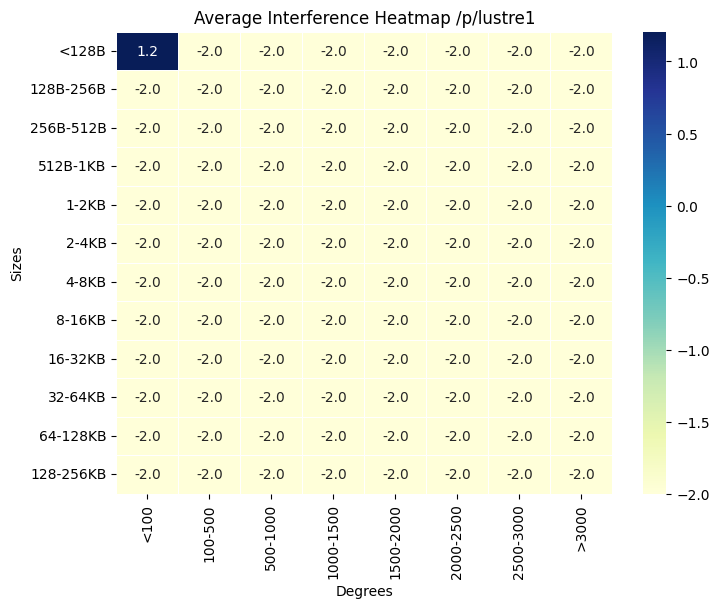

In [7]:

plot = GrepIOPlots()
#plot.hmap(mp='/p/gpfs1', df= events_obj.inter.compute(), size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)
plot.hmap(mp='/p/lustre1', df= events_obj.inter.compute(), size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

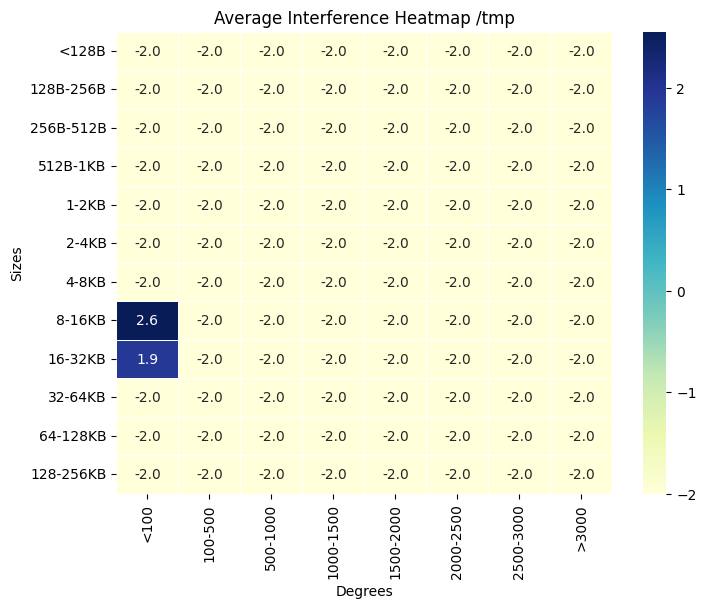

In [11]:
plot.hmap(mp='/tmp', df= events_obj.inter.compute(), size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

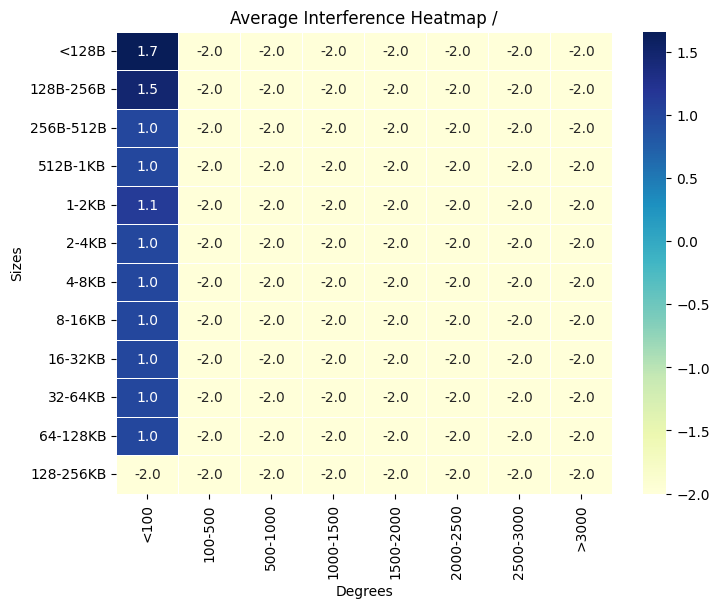

In [12]:
plot.hmap(mp='/', df= events_obj.inter.compute(), size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

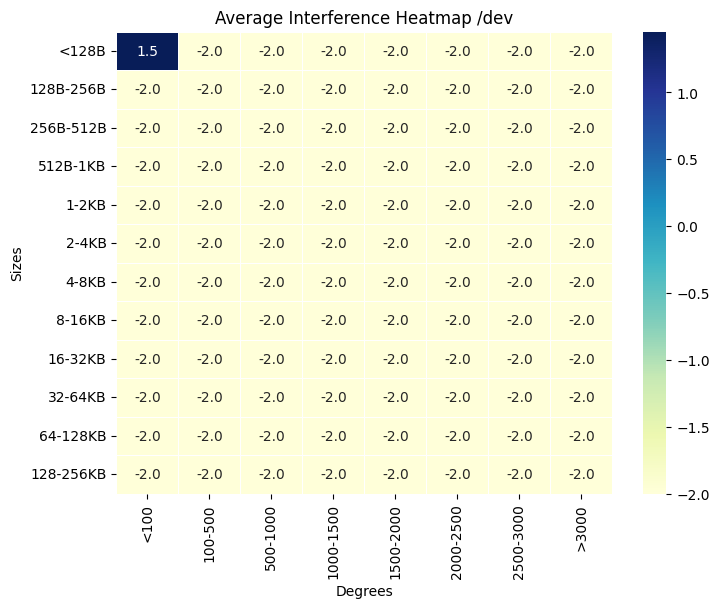

In [13]:
plot.hmap(mp='/dev', df= events_obj.inter.compute(), size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

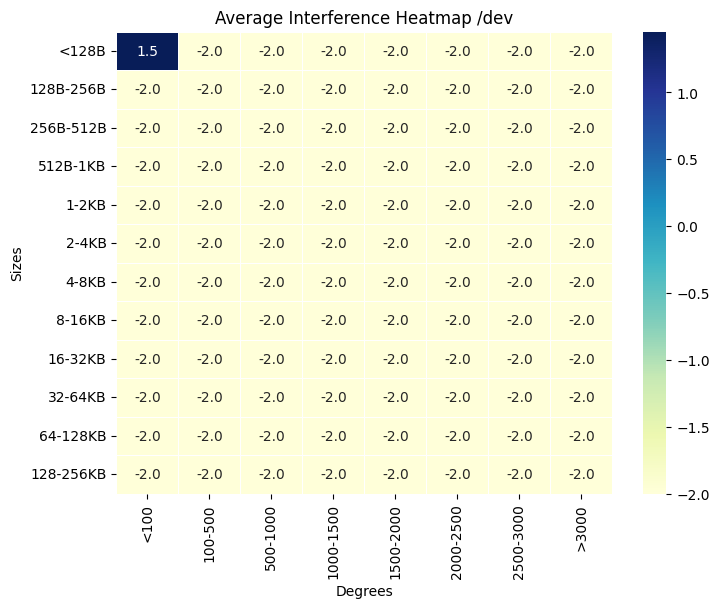

In [14]:
plot.hmap(mp='/dev', df= events_obj.inter.compute(), size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

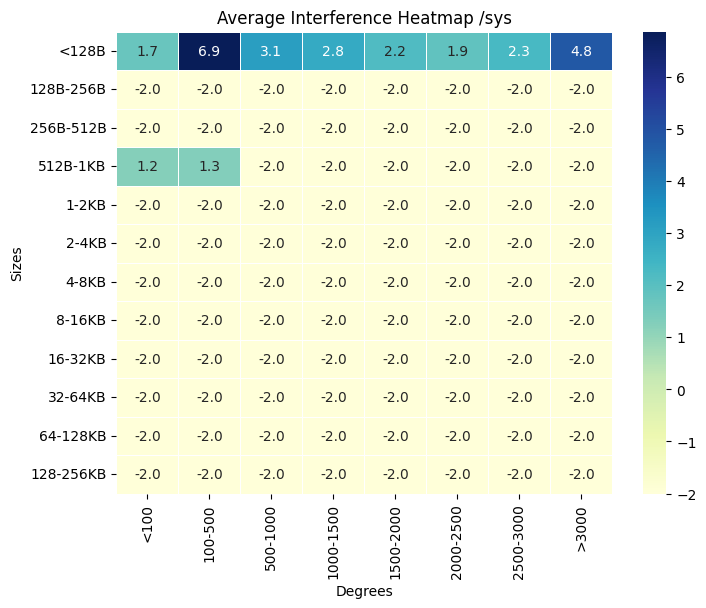

In [15]:
plot.hmap(mp='/sys', df= events_obj.inter.compute(), size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

In [16]:
# NOT USED AFTER THIS